In [34]:
%pip install pandas matplotlib seaborn numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
data='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
df=pd.read_csv(data)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


Look at the fuel_efficiency_mpg variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

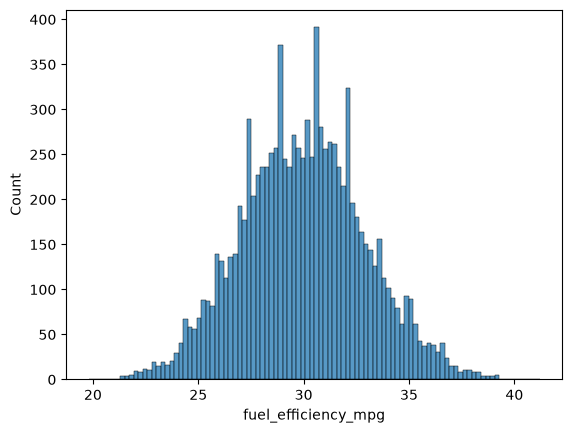

In [36]:
sns.histplot(df.fuel_efficiency_mpg, bins=100) 

Question 1: 
There's one column with missing values. What is it?

In [37]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

'horsepower'

Question 2: What's the median (50% percentile) for variable 'horsepower'?

In [38]:
df.horsepower.median()

np.float64(254.0)

In [39]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test

np.random.seed(42)
idx=np.arange(n)
np.random.shuffle(idx)

df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]]

df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

y_train=df_train.fuel_efficiency_mpg.values
y_val=df_val.fuel_efficiency_mpg.values
y_test=df_test.fuel_efficiency_mpg.values

In [40]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [41]:
def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])

    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [42]:
df_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
0,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3
1,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8
2,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8
3,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9
4,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6
...,...,...,...,...,...,...,...,...,...,...
5995,2018,Asia,Gasoline,Rear-wheel drive,4,2280,6,242.0,4590,20.5
5996,1984,Europe,Gasoline,Front-wheel drive,2,2300,6,NaN,4240,18.1
5997,1989,USA,Gasoline,Front-wheel drive,3,2240,6,255.0,4190,17.2
5998,2020,Europe,Gasoline,Rear-wheel drive,5,2430,6,254.0,4280,18.4


In [43]:
base=['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']

In [44]:
def prepare_X(df, f):
    df_num=df[base]
    df_num=df_num.fillna(f)
    X=df_num.values
    return X

In [45]:
X_train_zeros=prepare_X(df_train, 0)
w0_zeros, w_zeros=train_linear_regression(X_train_zeros, y_train)

X_val=prepare_X(df_val, 0)
y_pred_zeros=w0_zeros+X_val.dot(w_zeros)

In [46]:
mean=df_train['horsepower'].mean()
X_train_mean=prepare_X(df_train, mean)
w0_mean, w_mean=train_linear_regression(X_train_mean, y_train)

X_val=prepare_X(df_val, mean)
y_pred_mean=w0_mean+X_val.dot(w_mean)

In [47]:
def rmse(y,y_pred):
    se=(y-y_pred)**2
    mse=se.mean()
    return np.sqrt(mse)

Question 3: Which option gives better RMSE?

In [48]:
round(rmse(y_val, y_pred_zeros), 3)

np.float64(2.205)

In [49]:
round(rmse(y_val, y_pred_mean), 3)

np.float64(2.202)

Question 4: Which r gives the best RMSE?

In [50]:
def train_linear_regression_reg(X,y,r):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])

    XTX=X.T.dot(X)
    XTX=XTX+r*np.eye(XTX.shape[0])
    
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [51]:
X_train=prepare_X(df_train, 0)
X_val=prepare_X(df_val, 0)

In [52]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w=train_linear_regression_reg(X_train, y_train, r)
    y_pred=w0+X_val.dot(w)
    print(round(rmse(y_val, y_pred),4))

2.2053
2.2058
2.2241
2.3492
2.4094
2.4195
2.4292


Question 5: What's the value of std?

In [53]:
rmse_list=[]
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    idx=np.arange(n)
    np.random.shuffle(idx)

    df_train=df.iloc[idx[:n_train]]
    df_val=df.iloc[idx[n_train:n_train+n_val]]
    df_test=df.iloc[idx[n_train+n_val:]]

    df_train=df_train.reset_index(drop=True)
    df_val=df_val.reset_index(drop=True)
    df_test=df_test.reset_index(drop=True)

    y_train=df_train.fuel_efficiency_mpg.values
    y_val=df_val.fuel_efficiency_mpg.values
    y_test=df_test.fuel_efficiency_mpg.values

    X_train=prepare_X(df_train, 0)
    w0, w=train_linear_regression(X_train, y_train)

    X_val=prepare_X(df_val, 0)
    y_pred=w0+X_val.dot(w)

    rmse_list.append(rmse(y_val, y_pred))

print(round(np.std(rmse_list), 3))

0.029


Question 6: What's the RMSE on the test dataset?

In [54]:
df_full_train=pd.concat([df_train, df_val]).reset_index(drop=True)
X_full_train=prepare_X(df_full_train, 0)

y_full_train=np.concatenate([y_train, y_val])

w0, w=train_linear_regression_reg(X_full_train,y_full_train, 0.001)

X_test=prepare_X(df_test, 0)
y_pred=w0+X_test.dot(w)
rmse(y_test, y_pred)

np.float64(2.2358277471917636)